# **Applied Data Science in Medicine & Psychology - Assignment 9**
## Machine Learning
---
**Deadline: dd.mm.yyyy, hh:mm**
### **General Setup and Submission**
1. Save an editable copy of this notebook to your Google Drive ``File`` $\rightarrow$ ``Save a copy in Drive`` and remove the automatically appended "Copy of" text. **Do not change the original file name**.
2. Work on the assignment in the *copied* version of the notebook. Make sure that you **replace** all parts of the tasks indicated with *YOUR CODE HERE* and **raise NotImplementedError()** (otherwise this causes an error in your implementation) or *YOUR ANSWER HERE* with your solution.
3. If you take a break during the implementation, you can save the current status of your work in your repository following the submission instructions below. When you continue working on the assignment, do this in the version of the notebook that you saved in your Google Drive (access from your Google Colab account) or your repository.
4. After finishing the assignment submit your assignment as follows:
    * Check that everything runs as expected. To do that select in the menubar ``Runtime`` $\rightarrow$ ``Restart and run all``. This will clear all your local variables and runs your notebook from the beginning.
    * Save your notebook, click ``File`` $\rightarrow$ ``Save``
    * Click ``File`` $\rightarrow$ ``Save a copy in GitHub``
    * Select ``digikolleg-data-science-psychology/9-ml-<username>`` from the repository drop-down menu
    * Type ``9-ml.ipynb`` into the file path text box
    * Optionally, you may enter a description into the "Commit message" text box (like: "solved task 1" or "ready for grading")
    * Make sure that the "Include a link to Colaboratory" box is checked
    * Press "Ok"
    * A new tab or window should open up, displaying your submitted notebook within your GitHub repository

Before the assignment deadline, you can re-submit your assignment as often as you would like. This will update your assignment file in your assignment's repository.

### **Assignment Description**
In this assignment, you will learn how to work with different functionalities provided by the ``scikit-learn`` library (``sklearn``) which offers various tools for predictive data analysis. We will cover four of the eight steps of the Machine Learning pipeline (described in the lecture). The assignment is divided into two parts: the main assignment and Bonus Tasks. The Bonus Tasks offer additional points that are added on top of the points earned in all other assignments, providing an opportunity to further enhance your overall score.

#### **Assignment Goals**
You are going to learn the following things in this assignment:
1. how to apply standardization
2. how to extract new features using dimensionality reduction
3. how to split data into a training and test dataset
4. how to train and evaluate a classifier
5. how to predict values using a regression model 
6. how to assign labels using clustering algorithms

#### **Assignment Point Value**
This assignment is worth a total (up to) **19** points (5 Bonus points included). If your code passes all of the manual and automatic tests you will receive full credit.

### **Tasks** (14 points)
Make sure that you now work on your *copied* version of this assignment's notebook.

#### 0. Imports and Setup
Please **run** the cell below to import the libraries needed for this assignment.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
!pip install biopsykit
import biopsykit as bp
import seaborn as sns
import sklearn
import warnings
from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LinearRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, mean_squared_error
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.cluster import KMeans


[notice] A new release of pip is available: 23.0 -> 23.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


#### 1. Data Loading and Preparation
For the following tasks, we use the *Breast Cancer Wisconsin dataset* of the ``scikit-learn`` library. Have a look at the content and structure of the dataset (``dataset_cancer``):
* What is the dataset about? 
* How many instances (also called observations) and attributes (also called features) are included? 
* How many instances are within every class?

The relevant information needed for the assignment is stored within two data frames:
* ``data_cancer`` contains all instances as rows and the attributes as columns
* ``label_cancer`` indicates whether each breast cancer instance turned out to be malignant or benign

In [2]:
# run cell to load the dataset
dataset_cancer = load_breast_cancer()
data_cancer = pd.DataFrame(dataset_cancer["data"], columns=dataset_cancer["feature_names"])
label_cancer = pd.DataFrame(dataset_cancer["target"], columns=["label"])
label_cancer.loc[label_cancer["label"] == 0, ["label"]] = "malignant"
label_cancer.loc[label_cancer["label"] == 1, ["label"]] = "benign"
data_cancer.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
# run cell to see the labels
label_cancer.head()

,label
0,malignant
1,malignant
2,malignant
3,malignant
4,malignant


#### 2. Feature Visualization
* Visualize the features *mean radius*, *mean texture*, *mean smoothness*, *mean concavity*, and *mean symmetry* using a [seaborn.pairplot](https://seaborn.pydata.org/generated/seaborn.pairplot.html)
* Set the plot parameters such that you can differentiate between the classes
* Save the return values of the plot in a variable called ``pp``
* Have a look at the plot. Describe your thoughts about (in the cell below):
    * the distributions of the single features (diagonal). Why is it most of the time advantageous to include more than one feature in your analysis? 
    * the separability of classes
    * correlation between features

**Hint**: Concatenating all relevant data to a new data frame might help you to solve this task.

*YOUR ANSWER HERE*

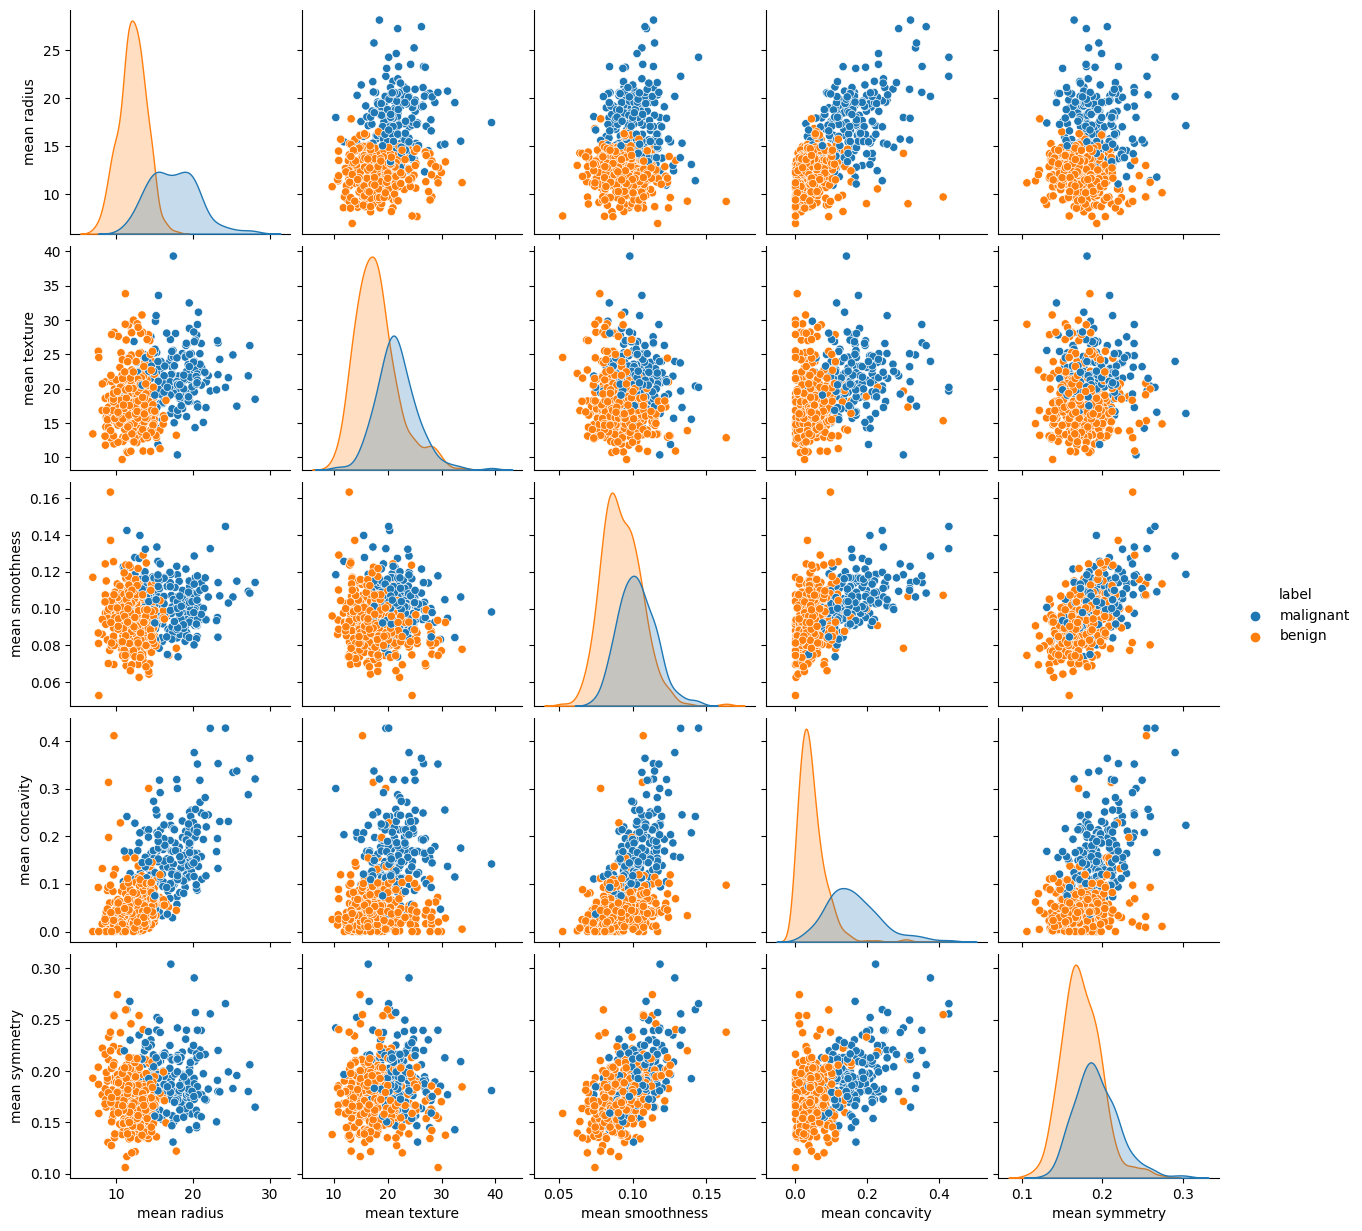

In [4]:
### BEGIN SOLUTION
data_plot = data_cancer.loc[:, ["mean radius", "mean texture", "mean smoothness", "mean concavity", "mean symmetry"]]
data_plot = pd.concat([data_plot, label_cancer], axis=1)
pp = sns.pairplot(data=data_plot, hue="label")
### END SOLUTION

In [5]:
# run cell to test your implementation
assert type(pp) == sns.axisgrid.PairGrid, "Check that you create a pairplot using the seaborn library"
assert pp.x_vars == pp.y_vars and np.shape(pp.axes) == (5, 5), "Check that you create a pairplot"
assert set(pp.x_vars) == {"mean concavity", "mean radius", "mean smoothness", "mean symmetry", "mean texture"}, "Check the features in the pairplot"
assert pp.legend is not None, "Make sure that you can differentiate between the classes"

#### 3. Standardization (step: Data Preparation)
Create two functions ``train_scaler`` and ``apply_scaler`` that apply [Standardization](https://scikit-learn.org/stable/modules/preprocessing.html) to the dataset:
* ``train_scaler`` has the parameter ``data`` and fits a Standard Scaler to ``data``:
    * ``data``: ``pandas.DataFrame`` containing the dataset (rows: observations, columns: features)
    * Create an instance of [sklearn.preprocessing.StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)
    * Use its methods to fit the scaler to ``data``
    * The function should return the trained scaler object
* ``apply_scaler`` has the parameter ``scaler`` and ``data``:
    * ``scaler``: trained instance of  [sklearn.preprocessing.StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)
    * ``data``: ``pandas.DataFrame`` containing the dataset (rows: observations, columns: features)
    * Use the methods of ``scaler`` to transform ``data`` such that every feature individually has zero mean and unit variance
    * The function should return an array containing a standardized version of ``data``
* Why do you think we have to split the fitting and transforming procedure into two separate functions? (answer in the cell below)

*YOUR ANSWER HERE*

In [6]:
### BEGIN SOLUTION
def train_scaler(data):
    scaler = StandardScaler()
    scaler.fit(data)
    return scaler

def apply_scaler(scaler, data):
    data_scaled = scaler.transform(data)
    return data_scaled
### END SOLUTION

In [7]:
# run cell to test your implementation
scaler = train_scaler(data_cancer)
assert type(scaler) == sklearn.preprocessing._data.StandardScaler, "Check that you train a Standard Scaler"
assert hasattr(scaler, "mean_"), "Ensure that you fit the Scaler to your data"
data_scaled = apply_scaler(scaler, data_cancer)
assert type(data_scaled) == np.ndarray, "Check that you return the standardized data as array"
assert np.shape(data_scaled) == (569, 30), "Check that you return value keeps the input dimensions"
assert np.sum(np.std(data_scaled, axis=0)) > 29.99, "Ensure that all features have unit variance after standardizing"
assert np.abs(np.sum(np.mean(data_scaled, axis=0))) < 1e-10, "Ensure that all features have zero mean after standardizing"

#### 4. Visualization Standardization
Create a figure with two subplots that visualizes 2 features of the original and standardized dataset:
* Create a figure with two subplots using [matplotlib.pyplot.subplots](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html) and save its return values in variables called ``fig`` and ``axs``
* Plot in the first subplot a scatter plot of *mean radius* and *mean texture* of the original dataset
* Plot in the second subplot a scatter plot of *mean radius* and *mean texture* of the standardized dataset
* Set x- and y-axis labels and the subplot titles according to the data
* Describe the effects that standardization has on the data (in the cell below)

**Hints**: Check the data type of the standardized data, how can you access its values? You can also set the parameters ``sharex`` and ``sharey`` of [matplotlib.pyplot.subplots](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html) to ``True`` to see some of the effects of standardization.

*YOUR ANSWER HERE*

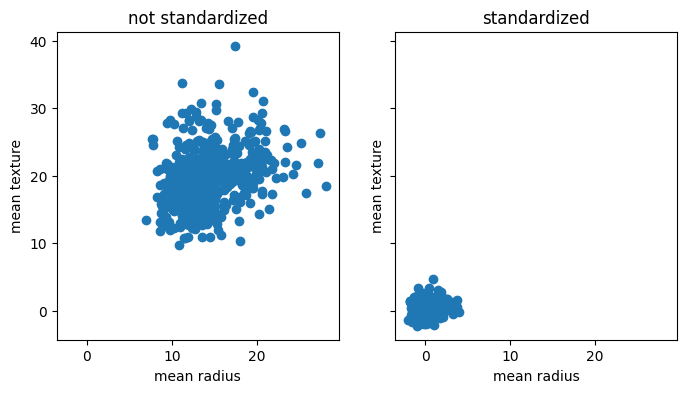

In [8]:
### BEGIN SOLUTION
scaler = train_scaler(data_cancer)
data_scaled = apply_scaler(scaler, data_cancer)
fig, axs = plt.subplots(ncols=2, figsize=(8, 4), sharex=True, sharey=True)
axs[0].scatter(data_cancer["mean radius"], data_cancer["mean texture"])
axs[1].scatter(data_scaled[:, 0], data_scaled[:, 1])
for ax in axs: ax.set_xlabel("mean radius"); ax.set_ylabel("mean texture")
for ax, t in zip(axs, ["not standardized", "standardized"]): ax.set_title(t)
### END SOLUTION

In [9]:
# run cell to test your implementation
assert len(fig.axes) == 2, "Ensure that you create a figure with two subplots"
assert np.all(np.abs(fig.axes[1].xaxis.get_data_interval()) < 5) and np.all(np.abs(fig.axes[1].yaxis.get_data_interval()) < 5), "Ensure that you visualize the standardized versions of mean radius and mean texture in the right subplot"
assert len(fig.axes[0].get_xlabel()) != 0 and len(fig.axes[0].get_ylabel()) != 0, "Check the first subplot's x and y labels"
assert len(fig.axes[0].title.get_text()), "Check the first subplot's title"
assert len(fig.axes[1].get_xlabel()) != 0 and len(fig.axes[1].get_ylabel()) != 0, "Check the second subplot's x and y labels"
assert len(fig.axes[1].title.get_text()), "Check the second subplot's title"

#### 5. Feature Visualization
* Visualize the features *mean radius*, *mean perimeter*, *mean area*, *worst radius*, and *worst perimeter* of the original dataset using a [seaborn.pairplot](https://seaborn.pydata.org/generated/seaborn.pairplot.html)
* Set the parameters such that you can differentiate between the classes
* Save the return values of the plot in a variable called ``pp``
* Have a look at the plot. Describe your thoughts about the correlation between features (in the cell below):

*YOUR ANSWER HERE*

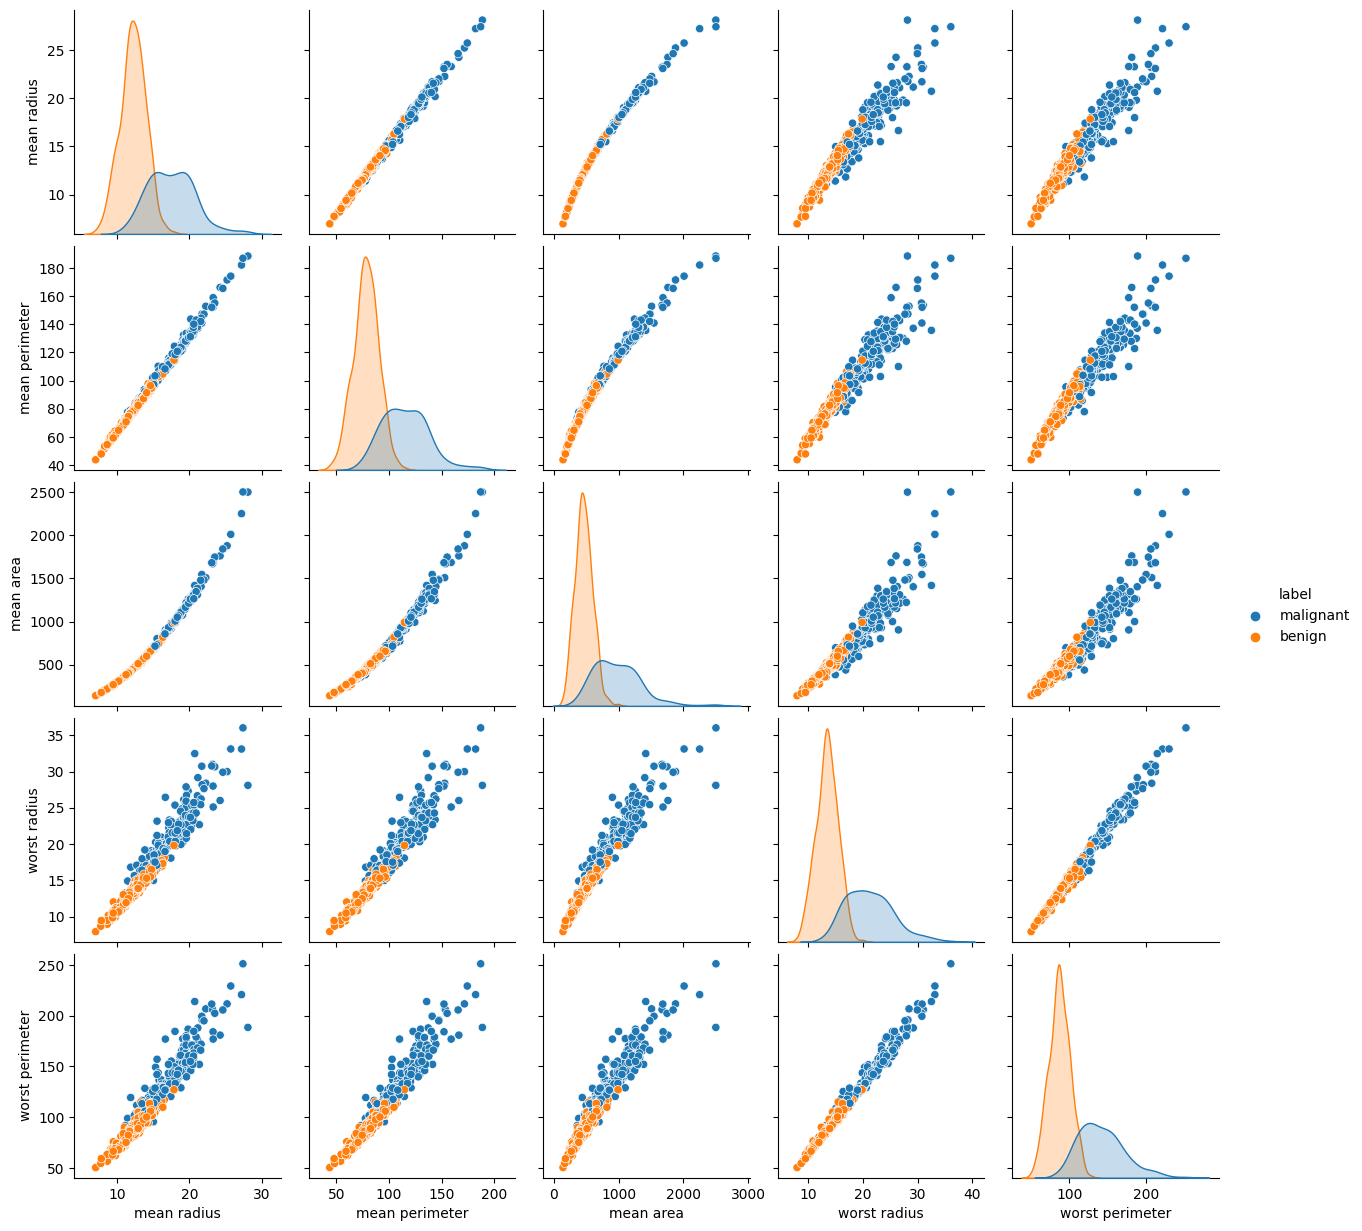

In [10]:
### BEGIN SOLUTION
data_plot = data_cancer.loc[:, ["mean radius", "mean perimeter", "mean area", "worst radius", "worst perimeter"]]
data_plot = pd.concat([data_plot, label_cancer], axis=1)
pp = sns.pairplot(data_plot, hue="label")
### END SOLUTION

In [11]:
# run cell to test your implementation
assert type(pp) == sns.axisgrid.PairGrid, "Check that you create a pairplot using the seaborn library"
assert pp.x_vars == pp.y_vars and np.shape(pp.axes) == (5, 5), "Check that you create a pairplot"
assert set(pp.x_vars) == {"mean area", "mean perimeter", "mean radius", "worst perimeter", "worst radius"}, "Check the features in the pairplot"
assert pp.legend is not None, "Make sure that you can differentiate between the classes"

#### 6. Dimensionality Reduction (step: Data Preparation)
Create two functions ``train_pca`` and ``apply_pca`` that apply [Principal Component Analysis (PCA)](https://scikit-learn.org/stable/modules/decomposition.html#decompositions) to the dataset:
* ``train_pca`` has the parameters ``data`` and ``n_components`` and fits a PCA to ``data``:
    * ``data``: ``numpy.ndarray`` or ``pandas.DataFrame`` containing the data (rows: observations, columns: features)
    * ``n_components``: number of principal components to be kept
    * Create an instance of [sklearn.decomposition.PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html). Set the parameters: *n_components*: ``n_components``, *svd_solver*: "full". Have a look at the *n_components* parameter, which options do you have to specify the parameter? 
    * Use its methods to fit the PCA to ``data`` 
    * The function should return the trained PCA object
* ``apply_pca`` has the parameters ``pca`` and ``data`` and transforms ``data`` using ``pca``:
    * ``pca``: trained instance of [sklearn.decomposition.PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)
    * ``data``: ``numpy.ndarray`` or ``pandas.DataFrame`` containing the data (rows: observations, columns: features)
    * Use the methods of ``pca`` to transform ``data``
    * The function should return an array containing the principal components

In [12]:
### BEGIN SOLUTION
def train_pca(data, n_components):
    pca = PCA(n_components=n_components, svd_solver="full")
    pca.fit(data)
    return pca

def apply_pca(pca, data):
    data_transformed = pca.transform(data)
    return data_transformed
### END SOLUTION

In [13]:
# run cell to test your implementation
pca = train_pca(data_cancer, 2)
assert type(pca) == sklearn.decomposition._pca.PCA, "Check that you train an return a PCA"
assert hasattr(pca, "components_"), "Ensure that you fit the PCA to your data"
data_pca = apply_pca(pca, data_cancer)
assert np.shape(data_pca) == (569, 2), "Check that you return the transformed data"
assert np.all(np.abs(np.mean(data_pca, axis=0)) < 1e-8), "Check that you return the transformed data"
assert np.all(np.mean(data_pca, axis=0) != data_cancer.mean(axis=0)[0:2].to_numpy()), "Check that you return the transformed data"
pca = train_pca(data_cancer, 0.8)
data_pca = apply_pca(pca, data_cancer)
assert np.shape(data_pca) == (569, 1), "Check that you accept also a value for explained variance as n_components"

#### 7. PCA Visualization
Use the functions of the tasks before to create two versions of the data set:
* ``data_pca``: consists of two principal components of the original data set
* ``data_scaled_pca``: consists of two principal components of the standardized data set

Run the cell below the tests to visualize the PCA results of the original and standardized data set.

In [14]:
### BEGIN SOLUTION
pca_1 = train_pca(data_cancer, 2)
data_pca = apply_pca(pca_1, data_cancer)

scaler = train_scaler(data_cancer)
data_scaled = apply_scaler(scaler, data_cancer)
pca_2 = train_pca(data_scaled, 2)
data_scaled_pca = apply_pca(pca_2, data_scaled)
### END SOLUTION

In [15]:
# run cell to test your implementation
assert np.shape(data_pca) == (569, 2),  "Check that you reduce the original dataset to two principal components"
assert np.std(data_pca) > 470, "Check that you apply pca to the original dataset in data_pca"
assert np.shape(data_scaled_pca) == (569, 2), "Check that you reduce the standardized dataset to two principal components"
assert np.std(data_scaled_pca) > 3, "Check that you standardized the data in data_scaled_pca before applying pca"

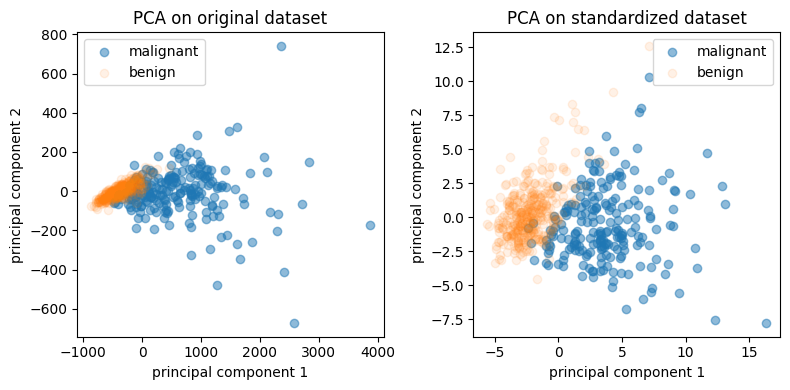

In [16]:
# run cell to visualize the PCA results of the original and standardized dataset 
fig, axs = plt.subplots(ncols=2, figsize=(8,4))

axs[0].scatter(data_pca[label_cancer["label"]=="malignant", 0], data_pca[label_cancer["label"]=="malignant", 1], alpha=0.5, label="malignant")
axs[0].scatter(data_pca[label_cancer["label"]=="benign", 0], data_pca[label_cancer["label"]=="benign", 1], alpha=0.1, label="benign")
axs[0].legend()

axs[1].scatter(data_scaled_pca[label_cancer["label"]=="malignant", 0], data_scaled_pca[label_cancer["label"]=="malignant", 1], alpha=0.5, label="malignant")
axs[1].scatter(data_scaled_pca[label_cancer["label"]=="benign", 0], data_scaled_pca[label_cancer["label"]=="benign", 1], alpha=0.1, label="benign")
axs[1].legend()

for ax, t in zip(axs, ["PCA on original dataset", "PCA on standardized dataset"]):
    ax.set_xlabel("principal component 1")
    ax.set_ylabel("principal component 2")
    ax.set_title(t)

fig.tight_layout()

#### 8. Train Test Split (step: Data Segregation)
Create a function ``split_data`` that takes the parameters ``data``, ``labels``, and ``test_size`` and splits ``data`` and ``labels`` into a training and test dataset:
* ``data``: ``numpy.ndarray`` or ``pandas.DataFrame`` containing the dataset (rows: observations, columns: features)
* ``labels``: ``numpy.ndarray`` or ``pandas.DataFrame`` containing the labels for all observations
* ``test_size``: ``float`` between 0 and 1, describing the size of the test dataset
* Use the [sklearn.model_selection.train_test_split()](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) function to generate a train test split from ``data`` and ``labels``
    * Use the *stratify* parameter of the function
    * Set the random state to 10
* The function should return a tuple of the into train and test dataset split dataset (in this order: data_train, data_test, label_train, label_test)
* Describe your thoughts about the following questions in the cell below:
    * Why do you think a Train Test Split is necessary for classifier training?
    * In which cases could stratification be important?

*YOUR ANSWER HERE*

In [17]:
### BEGIN SOLUTION
def split_data(data, labels, test_size):
    X_train, X_test, Y_train, Y_test = train_test_split(data, labels, test_size=test_size, stratify=labels, random_state=10)
    return X_train, X_test, Y_train, Y_test
### END SOLUTION

In [18]:
# run cell to test your implementation
data_test = np.array(range(100)).reshape(20, -1); label_test = np.zeros(20); label_test[2:] = 1
data_split = split_data(data_test, label_test, 0.3)
assert type(data_split) == tuple, "Check that you return a tuple of your return values"
assert np.shape(data_split[0]) == (14, 5) and np.shape(data_split[1]) == (6, 5) and np.shape(data_split[2]) == (14,) and np.shape(data_split[3]) == (6,), "Check that your return values are in the right order"
assert np.sum(data_split[3]) < 6, "Check that you set the stratify parameter correctly"

#### 9. Classification
In this task, you will create functions that you will later need to train a classifier and evaluate its performance. 
##### 9.1 Classifier Training (step: Model Training)
Create a function ``train_classifier`` with the parameters ``data`` and ``labels`` that fits a Support Vector Machine (SVM) to ``data``:
* ``data``: ``numpy.ndarray`` or ``pandas.DataFrame`` containing the dataset (rows: observations, columns: features)
* ``labels``: ``numpy.ndarray`` or ``pandas.DataFrame`` containing the labels for all observations
* Create an instance of [sklearn.svm.SVC](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html). Set the parameters *kernel*: "rbf", *random_state*: 10.
* Use its methods to fit the SVM to ``data`` and ``labels``
* The function should return the trained classifier object

In [19]:
### BEGIN SOLUTION
def train_classifier(data, labels):
    svc = SVC(kernel="rbf", random_state=10)
    svc.fit(data, labels)
    return svc
### END SOLUTION

In [20]:
# run cell to test your implementation
data_test = np.array(range(50)).reshape(10, -1); label_test = np.zeros(10); label_test[5:] = 1
clf = train_classifier(data_test, label_test)
assert type(clf) == sklearn.svm._classes.SVC, "Ensure that you train a classifier of type sklearn.svm.SVC"
assert clf.kernel == "rbf", "Ensure that you set your kernel to rbf"
assert clf.random_state == 10, "Ensure that you set the classifier's random_state to 10"
assert hasattr(clf, "classes_"), "Ensure that you train the classifier"

##### 9.2 Classifier Evaluation - Mean Accuracy (step: Model Evaluation)
Create a function ``calc_score`` with the parameters ``clf``, ``data``, and ``labels``
* ``clf``: trained classifier object
* ``data``: ``numpy.ndarray`` or ``pandas.DataFrame`` containing the dataset (rows: observations, columns: features)
* ``labels``: ``numpy.ndarray`` or ``pandas.DataFrame`` containing the labels for all observations
* Use the methods of ``clf`` to calculate the classifier's mean accuracy using ``data`` and ``labels``
* The function should return the mean accuracy

In [21]:
### BEGIN SOLUTION
def calc_score(clf, data, labels):
    return clf.score(data, labels)
### END SOLUTION

In [22]:
# run cell to test your implementation
data_test = np.array(range(50)).reshape(10, -1); label_test = np.zeros(10); label_test[5:] = 1
clf = train_classifier(data_test, label_test)
data_test = np.array(range(10, 60)).reshape(10, -1)
assert calc_score(clf, data_test, label_test) == 0.8, "Ensure that you calculate the accuracy using the trained classifier and the parameters data and labels"
### BEGIN HIDDEN TESTS
data_test = np.array(range(25, 75)).reshape(10, -1)
assert calc_score(clf, data_test, label_test) == 0.5
### END HIDDEN TESTS

##### 9.3 Classifier Evaluation - Confusion Matrix (step: Model Evaluation)
Create a function ``plot_confusion_matrix`` with the parameters ``clf``, ``data``, and ``labels`` that plots a confusion matrix according to the data:
* ``clf``: trained classifier object
* ``data``: ``numpy.ndarray`` or ``pandas.DataFrame`` containing the dataset (rows: observations, columns: features)
* ``labels``: ``numpy.ndarray`` or ``pandas.DataFrame`` containing the labels for all observations
* Use the example code of [sklearn.metrics.ConfusionMatrixDisplay](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html) to create a plot of a confusion matrix based on ``data`` and ``labels``
* The function should plot the confusion matrix and return the [sklearn.metrics.ConfusionMatrixDisplay](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html) object (just for testing purposes)

In [23]:
### BEGIN SOLUTION
def plot_confusion_matrix(clf, data, labels):
    predictions = clf.predict(data)
    cm = confusion_matrix(labels, predictions, labels=clf.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
    disp.plot()
    return disp
### END SOLUTION

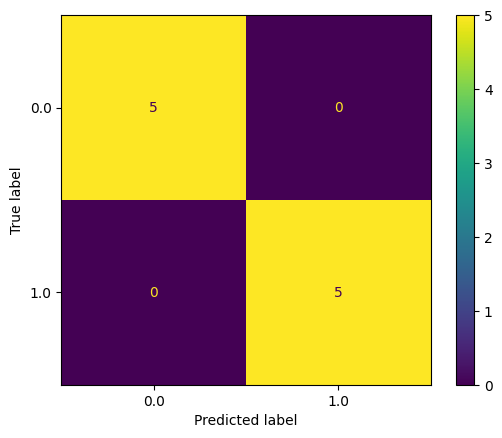

In [24]:
# run cell to test your implementation
data_test = np.array(range(50)).reshape(10, -1); label_test = np.zeros(10); label_test[5:] = 1
clf = train_classifier(data_test, label_test)
cm = plot_confusion_matrix(clf, data_test, label_test)
assert type(cm) == sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay
assert np.all(cm.confusion_matrix == np.array([[5, 0], [0, 5]]))

##### 9.4 Train a SVM classifier on a training data set and evaluate its performance on a separate test data set. To do so:
* Create a train test split of your data with a test size of 0.3
* Standardize the training data set and reduce its dimensionality to two components using PCA
* Train the classifier and save it in a variable called ``clf``
* Evaluate the performance of the trained classifier with the test data set:
    * Which steps do you have to perform on the independent test data set before?
    * Plot the confusion matrix for the test data set
    * Calculate the mean accuracy for the train and test data set separately. Store the values in variables called ``clf_train_acc`` and ``clf_test_acc``.

train: 0.9447236180904522
test: 0.935672514619883


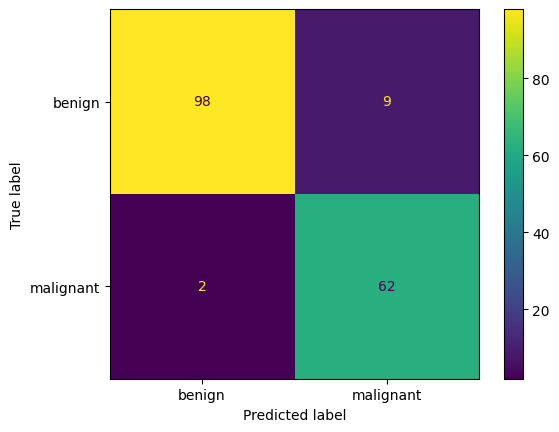

In [25]:
### BEGIN SOLUTION
X_train, X_test, Y_train, Y_test = split_data(data_cancer, label_cancer, 0.3)

scaler = train_scaler(X_train)
X_train_scaled = apply_scaler(scaler, X_train)
pca = train_pca(X_train_scaled, 2)
X_train_pca = apply_pca(pca, X_train_scaled)

clf = train_classifier(X_train_pca, Y_train.to_numpy().ravel())

X_test_scaled = apply_scaler(scaler, X_test)
X_test_pca = apply_pca(pca, X_test_scaled)

plot_confusion_matrix(clf, X_test_pca, Y_test)

clf_train_acc = calc_score(clf, X_train_pca, Y_train)
clf_test_acc = calc_score(clf, X_test_pca, Y_test)

print("train:", clf_train_acc)
print("test:", clf_test_acc)
### END SOLUTION

In [26]:
# run cell to test your implementation
assert clf_train_acc > 0.94 and clf_test_acc > 0.93, "Check that you perform all the steps you performed for the training data set also for the test data set"
assert clf.predict([[0, 5]])[0] == "benign" and clf.predict([[5, 0]])[0] == "malignant", "Check that you performed the Standardization and PCA on the training data set before training the classifier"

##### 9.5 Use the given function ``plot_decision_boundary()`` to visualize the decision boundary for your classifier:
* ``clf``: trained classifier
* ``data``: ``numpy.ndarray`` containing the training data set
* ``label``: ``pandas.DataFrame`` containing the labels for the training data set

In [27]:
def plot_decision_boundary(clf, data, label):
    x, y = np.meshgrid(np.linspace(data[:, 0].min(), data[:, 0].max()), np.linspace(data[:, 1].min(), data[:, 1].max()))
    grid = np.vstack([x.ravel(), y.ravel()]).T

    y_pred = np.reshape(clf.predict(grid), x.shape)
    y_pred[y_pred=="malignant"] = 0
    y_pred[y_pred=="benign"] = 1
    y_pred = np.array(y_pred, dtype=float)

    display = DecisionBoundaryDisplay(xx0=x, xx1=y, response=y_pred)
    display.plot()
    display.ax_.scatter(data[label["label"]=="malignant", 0], data[label["label"]=="malignant", 1], label="malignant", alpha=0.5)
    display.ax_.scatter(data[label["label"]=="benign", 0], data[label["label"]=="benign", 1], label="benign", alpha=0.5)
    display.ax_.legend()

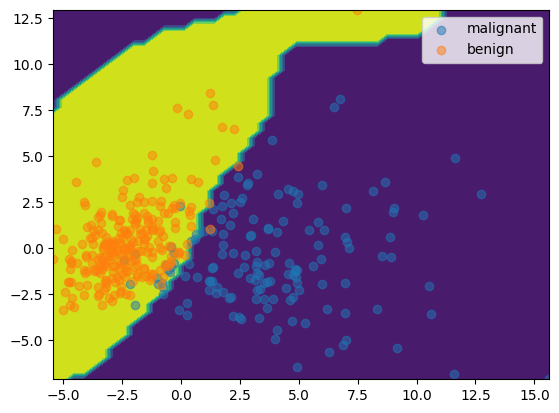

In [28]:
### BEGIN SOLUTION
plot_decision_boundary(clf, X_train_pca, Y_train)
### END SOLUTION

### **Bonus Tasks** (5 points)
The Bonus Tasks consist of three sub-tasks about Regression, Clustering, and Classification.
#### 1. Regression
In this task, we use the Diabetes dataset provided by ``sklearn``. The dataset includes four baseline features like age and body mass index and six blood serum measurements of 442 diabetes patients. All 10 features are standardized. As labels the response of interest, a quantitative measure of disease progression one year after baseline is provided. For more information, you can read the description provided by ``sklearn`` (``diabetes["DESCR"]``). The goal of this task is to predict the disease progression from the features using a regression model. For easier visualization, we will perform the regression only on one of the provided features. 

In [29]:
# run cell to load the diabetes features and label data frames
diabetes = load_diabetes()
data_diabetes = pd.DataFrame(data=diabetes["data"], columns=diabetes["feature_names"])
label_diabetes = pd.DataFrame(diabetes["target"], columns=["label"])
data_diabetes.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [30]:
label_diabetes.head()

,label
0,151.0
1,75.0
2,141.0
3,206.0
4,135.0


##### 1.1 Since we do not have distinct class values as labels, we cannot use the ``split_data()`` function from above to divide our data into a train and test dataset. Therefore, we will use the last 130 observations (approximately 30 %) as test dataset. Create four data frames called ``X_train``, ``X_test``, ``Y_train``, and ``Y_test``:
* ``X_Train`` should contain the first 312 elements of column **s5** of ``data_diabetes``
* ``X_Test`` should contain the last 130 elements of column **s5** of ``data_diabetes``
* ``Y_Train`` should contain the first 312 labels of ``label_diabetes``
* ``Y_Test`` should contain the last 130 labels of ``label_diabetes``

In [31]:
test_size = 130 # observations

### BEGIN SOLUTION
X_train = data_diabetes[["s5"]].iloc[:-test_size]
X_test = data_diabetes[["s5"]].iloc[-test_size:]
Y_train = label_diabetes.iloc[:-test_size]
Y_test = label_diabetes.iloc[-test_size:]
### END SOLUTION

In [32]:
# run cell to test your implementation
assert type(X_train) == pd.DataFrame and type(X_test) == pd.DataFrame and type(Y_train) == pd.DataFrame and type(Y_test) == pd.DataFrame, "Check that all four variables are of type pandas.DataFrame"
assert X_train.shape == (312, 1) and Y_train.shape == (312, 1) and X_test.shape == (130, 1) and Y_test.shape == (130, 1), "Check that you make the split correctly. The test set must have 130 observations"
assert X_train.sum()[0] > -0.8 and X_train.sum()[0] < -0.7, "Check that you use the last 130 observations as test set"

##### 1.2 Fit a Linear Regression to ``X_train`` and ``Y_train`` and evaluate the performance on ``X_test`` and ``Y_test``:
* Create an instance of [sklearn.linear_model.LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) called ``regr`` and use its methods to fit the model to ``X_train`` and ``Y_train``
* Calculate the Mean Squared Error between the true and predicted labels. You can use [sklearn.metric.mean_squared_error()](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html) for that. Save the value in a variable called ``test_error``.

In [33]:
### BEGIN SOLUTION
regr = LinearRegression()
regr.fit(X_train, Y_train)
Y_test_pred = regr.predict(X_test)
test_error = mean_squared_error(Y_test, Y_test_pred)
### END SOLUTION

print("Mean squared error: %.2f" % test_error)

Mean squared error: 4248.17


In [34]:
# run cell to test your implementation
assert type(regr) == sklearn.linear_model.LinearRegression, "Ensure that you train a Linear Regression Model"
assert hasattr(regr, "coef_"), "Ensure that you fit the Linear Regression model to the data"
warnings.simplefilter("ignore")
assert regr.predict([[0.3]])[0] > 448, "Ensure that you fit the model to the correct data"
assert test_error > 4245, "Ensure that you calculate the Mean Squared Error correctly"

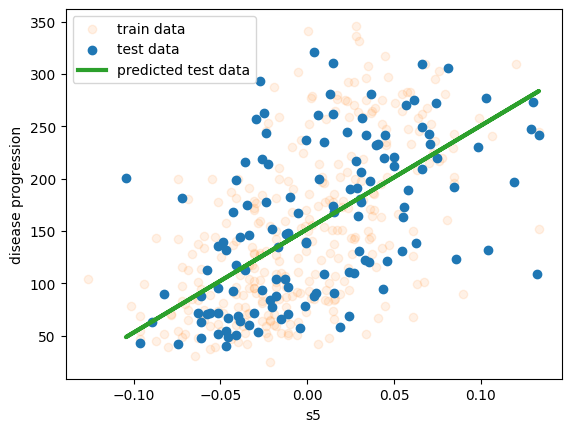

In [35]:
# run cell to visualize the results
fig, ax = plt.subplots()
ax.scatter(X_train, Y_train, color="tab:orange", alpha=0.1, label="train data")
ax.scatter(X_test, Y_test, color="tab:blue", label="test data")
ax.plot(X_test, Y_test_pred, color="tab:green", linewidth=3, label="predicted test data")
ax.legend()
ax.set_xlabel("s5")
_ = ax.set_ylabel("disease progression")

#### 2. Clustering
For the clustering task, we will use an artificial dataset consisting of three different Gaussian distributions which serve as three clusters. The goal of this task is to assign a label to every data point that indicates to which of the clusters they belong. 

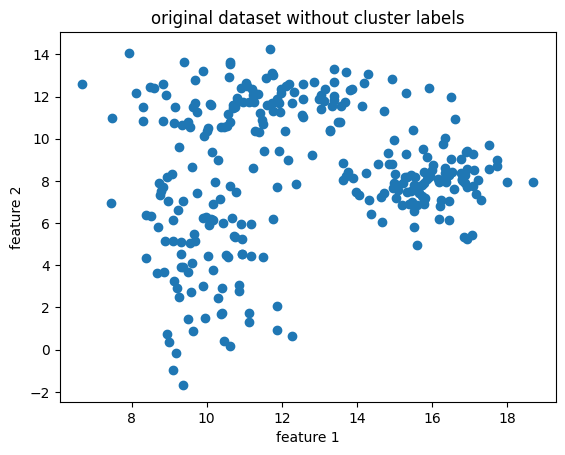

In [36]:
# run cell to create and visualize the artificial dataset
np.random.seed(0)
gauss_1 = np.random.normal(loc=(10, 5), scale=(1, 3), size=(100, 2))
gauss_2 = np.random.normal(loc=(12, 12), scale=(2, 1), size=(100, 2))
gauss_3 = np.random.normal(loc=(16, 8), scale=1, size=(100, 2))
data_cluster = np.concatenate([gauss_1, gauss_2, gauss_3])
fig, ax = plt.subplots()
ax.scatter(data_cluster[:, 0], data_cluster[:, 1])
ax.set_xlabel("feature 1")
ax.set_ylabel("feature 2")
_ = ax.set_title("original dataset without cluster labels")

##### 2.1 Use a K-Means Clustering algorithm to assign a cluster label to every data point in ``data_cluster``:
* Create an instance of [sklearn.cluster.KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) called ``kmeans``. Set the parameters *n_clusters*: 3, *random_state*: 10, *n_init*: "auto".
* Use ``kmeans`` methods to fit the model to ``data_cluster``
* Store the predicted labels in a variable called ``labels_pred``

In [37]:
### BEGIN SOLUTION
kmeans = KMeans(n_clusters=3, random_state=10, n_init="auto")
kmeans.fit(data_cluster)
labels_pred = kmeans.labels_
### END SOLUTION

In [38]:
# run cell to test your implementation
assert type(kmeans) == sklearn.cluster.KMeans, "Ensure that you use a KMeans model for clustering"
assert kmeans.n_clusters == 3 and kmeans.random_state == 10 and kmeans.n_init == "auto", "Check if you set the parameters of the KMeans model correctly"
assert hasattr(kmeans, "cluster_centers_"), "Ensure that you fit the KMeans model to the data"
assert np.shape(labels_pred) == (300,) and np.sum(labels_pred) > 300, "Ensure that you used the predicted labels of the trained KMeans model"

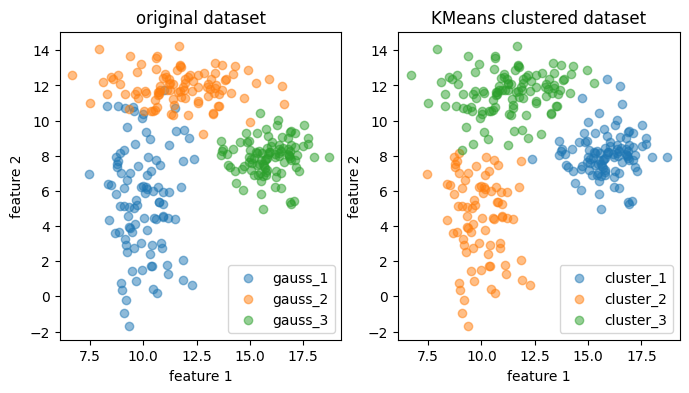

In [39]:
# run cell to visualize the results
fig, axs = plt.subplots(ncols=2, figsize=(8, 4))
axs[0].scatter(gauss_1[:, 0], gauss_1[:, 1], label="gauss_1", alpha=0.5)
axs[0].scatter(gauss_2[:, 0], gauss_2[:, 1], label="gauss_2", alpha=0.5)
axs[0].scatter(gauss_3[:, 0], gauss_3[:, 1], label="gauss_3", alpha=0.5)
axs[1].scatter(data_cluster[labels_pred==0, 0], data_cluster[labels_pred==0, 1], label="cluster_1", alpha=0.5)
axs[1].scatter(data_cluster[labels_pred==1, 0], data_cluster[labels_pred==1, 1], label="cluster_2", alpha=0.5)
_ = axs[1].scatter(data_cluster[labels_pred==2, 0], data_cluster[labels_pred==2, 1], label="cluster_3", alpha=0.5)
for ax, t in zip(axs, ["original dataset", "KMeans clustered dataset"]):
    ax.legend()
    ax.set_title(t)
    ax.set_xlabel("feature 1")
    ax.set_ylabel("feature 2")

#### 3. Classification
For the classification task, we use the cortisol data set that has been included in some of the last assignments. Five Saliva features are computed for 26 participants which are divided into two groups *Intervention* and *Control*. The goal of this task is to fit a Random Forest Classifier to different (sub-)sets of the dataset.

In [40]:
# run cell to load cortisol dataset
cortisol = bp.example_data.get_saliva_example()
sample_times = [-30, -1, 30, 40, 50, 60, 70]
auc = bp.saliva.auc(
    cortisol, saliva_type="cortisol", sample_times=sample_times, compute_auc_post=True, remove_s0=True
)
max_inc = bp.saliva.max_increase(cortisol, saliva_type="cortisol", remove_s0=True)
slope = bp.saliva.slope(cortisol, sample_idx=[1, 4], sample_times=sample_times, saliva_type="cortisol")

cort_features = pd.concat([auc, max_inc, slope], axis=1)
label_cortisol = np.array(cort_features.index.get_level_values(0))
data_cortisol = cort_features.droplevel(0, axis=0)
data_cortisol.head()

saliva_feature,cortisol_auc_g,cortisol_auc_i,cortisol_auc_i_post,cortisol_max_inc,cortisol_slope14
subject,,,,,
Vp03,870.418075,-72.035925,104.05725,0.95600,0.013971
Vp06,745.785975,305.071225,181.75300,9.44625,0.141828
Vp08,261.263925,84.065675,50.55200,3.01050,0.045958
Vp09,349.085125,-107.491025,0.65350,-1.40395,-0.027528
Vp11,477.073050,56.433550,19.71475,2.19135,0.042968


##### 3.1 Train the classifier on the complete dataset:
* Create an instance of [sklearn.ensemble.RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) called ``clf``. Set the parameters *n_estimators*: 100, *random_state*: 10.
* Use the methods of ``clf`` to fit the model to ``data_cortisol`` and ``label_cortisol``
* Calculate the mean accuracy of the dataset and save it in a variable ``data_score``
* Describe your thoughts about the following questions in the cell below:
    * How would you interpret this result? 
    * What can you tell about the generalizability of this model to unknown data?

*YOUR ANSWER HERE*

In [41]:
### BEGIN SOLUTION
n_est = 100
clf = RandomForestClassifier(n_estimators=n_est, random_state=10)
clf.fit(X=data_cortisol, y=label_cortisol)
data_score = clf.score(data_cortisol, label_cortisol)
### END SOLUTION

print("Classifier Data Score:", data_score)

Classifier Data Score: 1.0


In [42]:
# run cell to test your implementation
assert type(clf) == sklearn.ensemble.RandomForestClassifier, "Check if you train a classifer of type RandomForestClassifier"
assert clf.n_estimators == 100 and clf.random_state == 10, "Check the parameters of the classifier"
assert hasattr(clf, "classes_"), "Make sure that you fit the classifier"
warnings.simplefilter("ignore")
assert clf.predict([[300, 20, 40, 4, 0.03]])[0] == "Control" and clf.predict([[350, -10, 50, 0.7, 0]])[0] == "Intervention", "Make sure to train the classifier on the correct data set"
assert data_score == 1, "Make sure to train the classifier on the correct data set"

##### 3.2 Train the classifier on a train test split of the dataset:
* Create an instance of [sklearn.ensemble.RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) called ``clf``. Set the parameters *n_estimators*: 100, *random_state*: 10.
* Create a train test split of ``data_cortisol`` and ``label_cortisol`` using ``split_data()``. Use a test size of 0.3.
* Use the methods of ``clf`` to fit the model to the training dataset
* Calculate the mean accuracy of the training and test dataset separately and save it in variables called ``train_score`` and ``test_score``
* Describe your thoughts about the following questions in the cell below:
    * Why do you think is there such a big difference between that training and test model accuracy? 
    * What can you tell about the generalizability of this model to unknown data?

*YOUR ANSWER HERE*

In [43]:
### BEGIN SOLUTION
X_train, X_test, Y_train, Y_test = split_data(data_cortisol, label_cortisol, 0.3)
clf = RandomForestClassifier(n_estimators=n_est, random_state=10)
clf.fit(X=X_train, y=Y_train)
train_score = clf.score(X_train, Y_train)
test_score = clf.score(X_test, Y_test)
### END SOLUTION

print("Classifier Training Score:", train_score)
print("Classifier Test Score:", test_score)

Classifier Training Score: 1.0
Classifier Test Score: 0.625


In [44]:
# run cell to test your implementation
assert type(clf) == sklearn.ensemble.RandomForestClassifier, "Check if you train a classifer of type RandomForestClassifier"
assert clf.n_estimators == 100 and clf.random_state == 10, "Check the parameters of the classifier"
assert hasattr(clf, "classes_"), "Make sure that you fit the classifier"
warnings.simplefilter("ignore")
assert clf.predict([[350, 20, 40, 4, 0.03]])[0] == "Control" and clf.predict([[350, -10, 50, 0.7, 0]])[0] == "Intervention", "Make sure to train the classifier on the correct data set"
assert train_score == 1, "Make sure to train the classifier on the correct data set"
assert test_score == 0.625, "Make sure to calculate the accuracy for the separate test set"

##### 3.3 Train the classifier using Cross-Validation:
* Create an instance of [sklearn.ensemble.RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) called ``clf``. Set the parameters *n_estimators*: 100, *random_state*: 10.
* Use [sklearn.model_selection.cross_validate](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html) to train ``clf`` on the whole dataset using a 5-fold Cross-Validation. Set the parameter *cv*: 5
* Calculate the mean standard deviation over the 5 test scores and save them in the variables called ``test_score_mean`` and ``test_score_std``
* Describe you thoughts about the following questions in the cell below:
    * What are the advantages of using Cross-Validation? 
    * What can you tell about the robustness of this model?

*YOUR ANSWER HERE*

In [45]:
### BEGIN SOLUTION
clf = RandomForestClassifier(n_estimators=n_est, random_state=10)
scores = cross_validate(clf, data_cortisol, label_cortisol, cv=5, return_train_score=True)
test_score = scores["test_score"]
test_score_mean = np.mean(test_score)
test_score_std = np.std(test_score)
### END SOLUTION

# print("Mean squared error: %.2f" % test_error)
print("Classifier Test score (mean \u00B1 std): %.2f \u00B1 %.2f" % (test_score_mean, test_score_std))

Classifier Test score (mean ± std): 0.66 ± 0.12


In [46]:
# run cell to test your implementation
assert type(clf) == sklearn.ensemble.RandomForestClassifier, "Check if you train a classifer of type RandomForestClassifier"
assert clf.n_estimators == 100 and clf.random_state == 10, "Check the parameters of the classifier"
assert hasattr(clf, "classes_") == False, "Make sure to train the classifiers using cross_validate"
assert test_score_mean > 0.6 and test_score_std > 0.11, "Make sure to calculate the mean accuracy and standard deviation from the return values from cross_validate()"